In [1]:
import pandas as pd
import numpy as np

from data_preprocessing import *
from feature_engineering import *
from prob_forecasting import *
from qty_forecasting import *
from toolkit import *

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 设置 rcParams 默认值
import matplotlib
matplotlib.rc("font",family='Microsoft YaHei')

sns.set_style("whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc("axes",
        labelweight="bold", # 标签粗细
        labelsize="large", # 标签字体
        titleweight="bold", # 标题粗细
        titlesize=16, # 标题字体
        titlepad=10,
      )
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

## Settings

In [ ]:
TAR_YM = 202604
MTD = 5
IS_VALID = True
IS_MTD = False

## 1. 数据接入

In [23]:
from pathlib import Path

def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'code').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Cannot locate repository root containing code/ and data/')

REPO_ROOT = find_repo_root()
df_raw = pd.read_csv(REPO_ROOT / 'data' / 'sales_1m_hospital_daily.csv')
df_raw['transdate'] = pd.to_datetime(df_raw['transdate'])
df_ori = df_raw.groupby(['tomdmcode','bizym','transdate'])['qty'].sum().reset_index().sort_values(by=['tomdmcode','bizym']).reset_index(drop=True)

In [ ]:
df_ori_ym = df_ori.groupby(['bizym'])[['qty']].sum().reset_index()
fig = px.scatter(data_frame=df_ori_ym, x=df_ori_ym['bizym'].astype(str), y=df_ori_ym['qty'], color_discrete_sequence=['yellowgreen'])
fig.add_trace(go.Scatter(x=df_ori_ym['bizym'].astype(str), 
                        y=df_ori_ym['qty'], 
                        mode='lines', 
                        line=dict(color='purple', width=2),
                        showlegend=False))
fig.add_vline(
    x=12,
    line_dash="dash",
    line_color="red",
    line_width=2,
    opacity=0.5,
    # 可选：添加标注文本
    annotation_text="2025",
    annotation_position="top"
)
fig.add_vline(
    x=24,
    line_dash="dash",
    line_color="red",
    line_width=2,
    opacity=0.5,
    # 可选：添加标注文本
    annotation_text="2026",
    annotation_position="top"
)
fig.update_xaxes(title='transdate')
fig.update_yaxes(title='Sellin')
fig.update_layout(
    template='simple_white',
    title='DUPI',
    xaxis_tickangle=45,
    width=800, 
    height=400
)

## 2. 数据预处理

+ 仅对训练数据处理退货记录
+ 在评估测试数据时将退货视为0

In [25]:
processor = DataPreprocessing(df_ori, TAR_YM, cutoff_ym=202301, is_vaild=IS_VALID)

2026-06-12 17:22:42,711 - DP - INFO | 预测月份：202604


In [26]:
# 1、对训练数据移除退货记录
df_no_returns = processor.process_return_records(processor.df_train)
# 2、保留近一年有进货医院
df_data, df_log = processor.get_target_inst(df_no_returns)

2026-06-12 17:23:09,954 - DP - INFO | 退货记录处理完成：剩余0条退货记录
2026-06-12 17:23:10,010 - DP - INFO | 近一年内有进货医院：4062家
2026-06-12 17:23:10,013 - DP - INFO | 当月产生流向医院：2654家
2026-06-12 17:23:10,020 - DP - INFO | 属于近一年内有进货医院2559家（122597.5盒）
2026-06-12 17:23:10,027 - DP - INFO | 首次/一年前进货医院：95家（347.5盒）


## 3. 特征工程

In [27]:
# ！！！根据月份调整参数
PROB_WINDOW = 12
QTY_WINDOW = 12

In [28]:
jump_ym = [202401, 202403, 202409, 202411, 202501, 202503, 202509, 202511]
drop_ym = [202402, 202404, 202410, 202412, 202502, 202504, 202510, 202512]

In [29]:
generator = FeatureEngineering(df_data, TAR_YM, MTD, cutoff_ym=202401)

In [30]:
df_prob_ft, df_qty_ft = generator.get_prob_qty_ft(jump_ym, drop_ym, dur_prob=PROB_WINDOW, dur_qty=QTY_WINDOW)

2026-06-12 17:23:11,916 - FE - INFO | 年月对齐完成
2026-06-12 17:23:11,995 - FE - INFO | 时间特征完成
2026-06-12 17:23:12,133 - FE - INFO | 滞后特征完成
2026-06-12 17:23:20,852 - FE - INFO | RFM特征完成
2026-06-12 17:23:20,860 - FE - INFO | 趋势特征完成
2026-06-12 17:23:21,826 - FE - INFO | 进货月数完成
2026-06-12 17:23:24,065 - FE - INFO | 增长率完成
2026-06-12 17:23:24,235 - FE - INFO | 增/跌幅特征完成
2026-06-12 17:23:24,447 - FE - INFO | MTD特征完成
2026-06-12 17:23:25,943 - FE - INFO | 进货间隔特征完成
2026-06-12 17:23:26,282 - FE - INFO | 年月距离完成
2026-06-12 17:23:27,404 - FE - INFO | 距离月数完成
2026-06-12 17:23:32,452 - FE - INFO | 正常消耗完成
2026-06-12 17:23:32,461 - FE - INFO | 库存压力完成
2026-06-12 17:23:58,402 - FE - INFO | 库存代理完成
2026-06-12 17:23:58,463 - FE - INFO | 概率模型时间窗口：过去12个月
2026-06-12 17:23:58,464 - FE - INFO | 数量模型时间窗口：过去12个月


In [31]:
df_prob_ft.columns

Index(['tomdmcode', 'bizym', 'month', 'quarter', 'is_jump_ym', 'is_drop_ym',
       'ym_num', 'num_sellin_ym', 'num_wd', 'freq6m', 'freq3m',
       'freq6m_per_month', 'freq3m_per_month', 'recency', 'has_trans_6m',
       'has_trans_3m', 'DayDiffMean3m', 'DayDiffMean6m', 'DayDiffMean12m',
       'is_exceed_diff12m', 'is_exceed_diff6m', 'is_exceed_diff3m',
       'recency_months', 'stock_ratio_3m', 'stock_ratio_6m',
       'weighted_stock_ratio', 'last_spike', 'delta_stock_proxy', 'mtd_qty',
       'is_sellin'],
      dtype='object')

In [32]:
df_qty_ft = df_qty_ft.drop(columns=['bc_med'])
df_qty_ft.columns

Index(['tomdmcode', 'bizym', 'month', 'quarter', 'is_jump_ym', 'is_drop_ym',
       'ym_num', 'num_sellin_ym', 'num_wd', 'qty_lag_1', 'qty_lag_3',
       'qty_lag_6', 'qty_lag_12', 'mnt6m', 'mnt3m', 'mnt6m_per_month',
       'mnt3m_per_month', 'freq6m', 'freq3m', 'freq6m_per_month',
       'freq3m_per_month', 'mnt6m_per_trans', 'mnt3m_per_trans',
       'mnt3m_div_6m', 'recency', 'delta_qty_6m', 'delta_qty_3m',
       'has_trans_6m', 'has_trans_3m', 'growth_lag_1', 'growth_lag_2',
       'growth_lag_3', 'growth_lag_6', 'growth_lag_12', 'growth_jump',
       'growth_drop', 'stock_ratio_3m', 'stock_ratio_6m',
       'weighted_stock_ratio', 'last_spike', 'delta_stock_proxy', 'mtd_qty',
       'ttl_qty'],
      dtype='object')

# 4. 进货概率预测

In [33]:
classifier = ProbForecasting(df_prob_ft, TAR_YM, MTD, IS_VALID, IS_MTD)

In [34]:
# OPTION I: Baseline
base_fts = classifier.apply_baseline()

# OPTION II: RFE
# sel_fts = classifier.apply_rfe()

2026-06-12 17:23:59,223 - PF - INFO | Baseline Valid Accuracy: 82.79
2026-06-12 17:23:59,228 - PF - INFO | 直接训练 + 验证完毕


---

**选择策略**

In [35]:
CLS_STRAT = "Baseline"

2026-06-12 17:24:00,118 - PF - INFO | 进货概率预测完毕
2026-06-12 17:24:00,130 - PF - INFO | Test Accuracy: 83.33
2026-06-12 17:24:00,214 - PF - INFO | 是否进货打标完毕


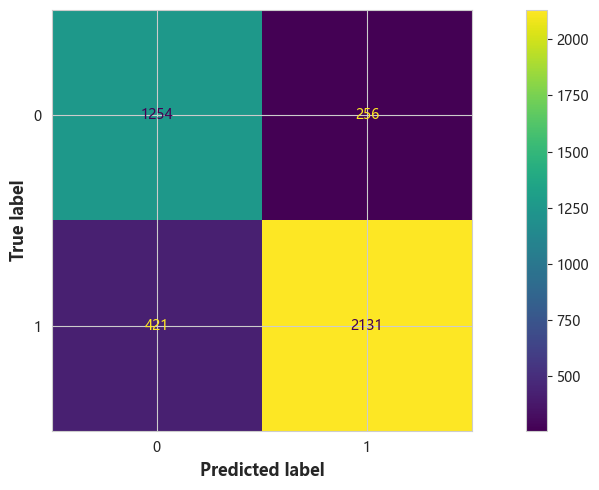

In [ ]:
if CLS_STRAT == "Baseline":
    df_prob, df_imp_prob = classifier.forecasting(base_fts)
# elif CLS_STRAT == "RFE":
#     df_prob, df_imp_prob = classifier.forecasting(sel_fts)


cut_thr = classifier.get_prob_thr(df_prob)
df_prob = classifier.get_is_sellin_label(df_prob, cut_thr)

# 5. 进货数量预测

In [37]:
regressor = QtyForecasting(df_qty_ft, TAR_YM, MTD, IS_VALID, IS_MTD)

In [38]:
def process_fcst_value(df_prob, df_fcst):
    df_fcst = df_fcst.merge(df_prob[['tomdmcode','bizym','fcst_label']], how='left', on=['tomdmcode','bizym'])
    # 1-预测负数，抹0
    df_fcst.loc[df_fcst['fcst_qty']<0, 'fcst_qty'] = 0
    # 2-总量少于MTD，使用MTD数量
    # df_fcst.loc[df_fcst['fcst_qty']<df_fcst['mtd_qty'], 'fcst_qty'] = df_fcst[df_fcst['fcst_qty']<df_fcst['mtd_qty']]['mtd_qty']
    # 3-根据进货概率模型输出，将预测不进货的医院设为0
    df_fcst.loc[df_fcst['fcst_label']==0, 'fcst_qty'] = 0
    return df_fcst

**Baseline**

In [39]:
df_fcst_base, df_imp_base = regressor.apply_baseline()
df_fcst_base = regressor.process_fcst_value(df_prob, df_fcst_base)

2026-06-12 17:24:02,420 - QF - INFO | Baseline Valid Error: 0.25%
2026-06-12 17:24:02,423 - QF - INFO | Baseline Valid RMSE: 22.11
2026-06-12 17:24:02,424 - QF - INFO | 直接训练 + 验证完毕


In [40]:
print('Fcst Inst', df_fcst_base[df_fcst_base['fcst_qty']>0]['tomdmcode'].nunique())
if IS_VALID:
    print('Actual Inst', df_fcst_base[df_fcst_base['ttl_qty_pos']>0]['tomdmcode'].nunique())
    print('Total Error', round((df_fcst_base['fcst_qty'].sum() / df_fcst_base['ttl_qty_pos'].sum() - 1) * 100, 2))

Fcst Inst 2381
Actual Inst 2552
Total Error -10.09


In [41]:
print(df_fcst_base['fcst_qty'].sum())

109820.516


**分层预测**

,group,tomdmcode_count,mnt3m_mean,mnt3m_min,mnt3m_max,has_trans_3m_mean
0,1,1904,161.083246,1.5,5605.0,3.0
1,2,609,18.636289,1.5,326.0,2.0
2,3,709,7.188293,0.5,924.0,1.0
3,4,840,0.000000,0.0,0.0,0.0


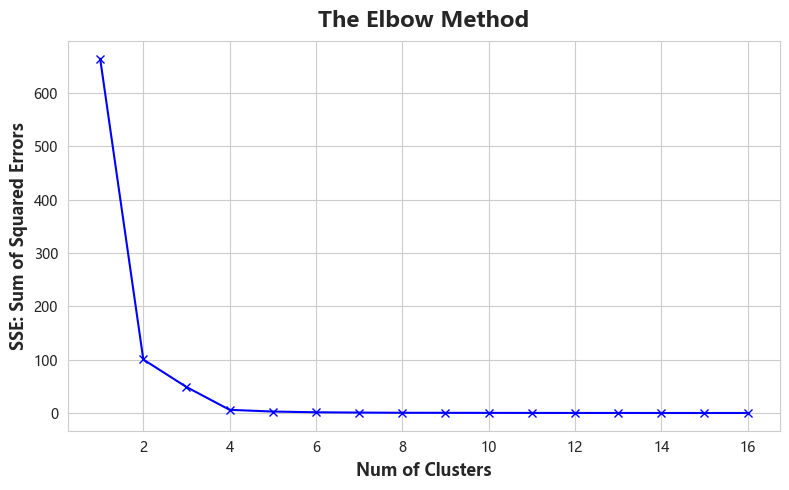

In [42]:
cls_ft_list = ['mnt3m','has_trans_3m']
key_ft = 'mnt3m'
df_cluster, df_info = regressor.apply_clustering(cls_ft_list,key_ft,base_k=4,sse_thr=5,k=0)
df_info

In [43]:
df_fcst_rfm, df_imp_rfm = regressor.apply_rfm(df_cluster, df_info) 
df_fcst_rfm = regressor.process_fcst_value(df_prob, df_fcst_rfm)
df_fcst_rfm = df_fcst_rfm.merge(df_cluster[['tomdmcode','group']], how='left', on=['tomdmcode'])

2026-06-12 17:24:07,473 - QF - INFO | Group 1
2026-06-12 17:24:08,333 - QF - INFO | Valid RMSE: 31.96
2026-06-12 17:24:09,132 - QF - INFO | Valid Error%: -0.14%
2026-06-12 17:24:09,150 - QF - INFO | ==============================
2026-06-12 17:24:09,155 - QF - INFO | Group 2
2026-06-12 17:24:09,661 - QF - INFO | Valid RMSE: 10.32
2026-06-12 17:24:10,122 - QF - INFO | Valid Error%: -0.26%
2026-06-12 17:24:10,139 - QF - INFO | ==============================
2026-06-12 17:24:10,146 - QF - INFO | Group 3
2026-06-12 17:24:10,536 - QF - INFO | Valid RMSE: 27.36
2026-06-12 17:24:10,959 - QF - INFO | Valid Error%: 0.05%
2026-06-12 17:24:10,976 - QF - INFO | ==============================
2026-06-12 17:24:10,980 - QF - INFO | Group 4
2026-06-12 17:24:11,447 - QF - INFO | Valid RMSE: 0.51
2026-06-12 17:24:11,874 - QF - INFO | Valid Error%: -inf%
2026-06-12 17:24:11,892 - QF - INFO | ==============================
2026-06-12 17:24:11,901 - QF - INFO | RFM Valid Error: -0.15%
2026-06-12 17:24:11,9

In [44]:
print('Fcst Inst', df_fcst_rfm[df_fcst_rfm['fcst_qty']>0]['tomdmcode'].nunique())
if IS_VALID:
    print('Actual Inst', df_fcst_rfm[df_fcst_rfm['ttl_qty_pos']>0]['tomdmcode'].nunique())
    print('Total Error', round((df_fcst_rfm['fcst_qty'].sum() / df_fcst_rfm['ttl_qty_pos'].sum() - 1) * 100, 2))

Fcst Inst 2357
Actual Inst 2552
Total Error -10.12


In [45]:
print(df_fcst_rfm['fcst_qty'].sum())

109791.766


---

**选择策略**

In [50]:
df_ori_ym = df_ori.groupby(['bizym'])[['qty']].sum().reset_index()
df_ori_ym = df_ori_ym[df_ori_ym['bizym']<TAR_YM]
fig = px.scatter(data_frame=df_ori_ym, x=df_ori_ym['bizym'].astype(str), y=df_ori_ym['qty'], color_discrete_sequence=['yellowgreen'])
fig.add_trace(go.Scatter(x=df_ori_ym['bizym'].astype(str), 
                        y=df_ori_ym['qty'], 
                        mode='lines', 
                        line=dict(color='purple', width=2),
                        name='月度曲线'))
fig.add_vline(
    x=12,
    line_dash="dash",
    line_color="red",
    line_width=2,
    opacity=0.5,
    # 可选：添加标注文本
    annotation_text="2025",
    annotation_position="top"
)
fig.add_vline(
    x=24,
    line_dash="dash",
    line_color="red",
    line_width=2,
    opacity=0.5,
    # 可选：添加标注文本
    annotation_text="2026",
    annotation_position="top"
)

fig.add_trace(go.Scatter(
    x = [str(TAR_YM)], 
    y = [df_fcst_base['fcst_qty'].sum()], 
    mode = 'markers', 
    line = dict(color='skyblue', width=2),
    name = 'Baseline'
))
fig.add_trace(go.Scatter(
    x = [str(TAR_YM)], 
    y = [df_fcst_rfm['fcst_qty'].sum()], 
    mode = 'markers', 
    line = dict(color='royalblue', width=2),
    name = 'RFM'
))
fig.update_xaxes(title='YYYYMM')
fig.update_yaxes(title='Sellin Qty')
fig.update_layout(template='simple_white',
                title=f'Dupixent',
                width=800, 
                height=400,
                xaxis=dict(
                    tickangle=45,  # 顺时针旋转45度，负数则逆时针
            ))

In [47]:
REG_STRAT = "RFM"

In [48]:
if REG_STRAT == "Baseline":
    df_fcst = df_fcst_base
    df_imp_qty = df_imp_base
elif REG_STRAT == "RFM":
    df_fcst = df_fcst_rfm
    df_imp_qty = df_imp_rfm

# 6. 合理性分析

In [51]:
df_ym_with_fcst = df_ori_ym.copy()
df_ym_with_fcst.loc[len(df_ori_ym)] = [TAR_YM, df_fcst_rfm['fcst_qty'].sum()]
df_ym_with_fcst

,bizym,qty
0,202401.0,54057.000000
1,202402.0,39519.250000
2,202403.0,57283.000000
3,202404.0,56806.500000
4,202405.0,67069.500000
5,202406.0,61625.250000
6,202407.0,64876.000000
7,202408.0,70090.500000
8,202409.0,76223.250000
9,202410.0,54625.000000


In [52]:
ym_13 = get_previous_month(TAR_YM,13)
ym_12 = get_previous_month(TAR_YM,12)
ym_1 = get_previous_month(TAR_YM,1)
qty_13 = df_ym_with_fcst[df_ym_with_fcst['bizym']==ym_13]['qty'].values[0]
qty_12 = df_ym_with_fcst[df_ym_with_fcst['bizym']==ym_12]['qty'].values[0]
qty_1 = df_ym_with_fcst[df_ym_with_fcst['bizym']==ym_1]['qty'].values[0]
qty_0 = df_ym_with_fcst[df_ym_with_fcst['bizym']==TAR_YM]['qty'].values[0]

In [53]:
ym_list = []
growth_yoy_list = []
growth_cur_list = []
for i in range(6,0,-1):
    ym = get_previous_month(TAR_YM, i)
    ym_list.append(ym)
    growth_yoy, growth_cur = calculate_yoy_growth(df_ym_with_fcst, ym)
    growth_yoy_list.append(round(growth_yoy,3))
    growth_cur_list.append(round(growth_cur,3))
ym_list.append(TAR_YM)
growth_yoy_list.append(round(qty_12/qty_13-1,3))
growth_cur_list.append(round(qty_0/qty_1-1,3))
df_growth = pd.DataFrame({
    'ym': ym_list,
    'gyoy':growth_yoy_list,
    'gcur':growth_cur_list
})
df_growth

,ym,gyoy,gcur
0,202510,-0.283,-0.246
1,202511,0.187,0.153
2,202512,-0.319,-0.039
3,202601,1.123,0.167
4,202602,-0.254,-0.217
5,202603,0.414,0.267
6,202604,-0.055,-0.049


In [54]:
fig_growth = go.Figure()
fig_growth.add_trace(go.Scatter(
    x = df_growth['ym'].astype(str), 
    y = df_growth['gyoy'], 
    mode = 'lines+markers', 
    line = dict(color='purple', width=2),
    name = '去年同月环比'
))
fig_growth.add_trace(go.Scatter(
    x = df_growth['ym'].astype(str), 
    y = df_growth['gcur'], 
    mode = 'lines+markers', 
    line = dict(color='green', width=2),
    name = '当前月环比'
))
fig_growth.update_xaxes(title='YYYYMM')
fig_growth.update_yaxes(title='Growth')
fig_growth.update_layout(
    template='simple_white',
    title=f'MoM Growth',
    width=800, 
    height=400
)

# 7. 医院分级标签

In [55]:
def get_terms(df, ym):
    ym_full = get_previous_month(ym, 12)
    inst_has_trans = df[(df['bizym']>=ym_full) & (df['bizym']<ym)]['tomdmcode'].unique()
    return inst_has_trans

In [56]:
codes_l3 = get_terms(df_no_returns, get_previous_month(TAR_YM, 3))
codes_l2 = get_terms(df_no_returns, get_previous_month(TAR_YM, 2)) 
codes_l1 = get_terms(df_no_returns, get_previous_month(TAR_YM, 1)) 
codes_int = list(set(codes_l3)&set(codes_l2)&set(codes_l1))

In [57]:
df_level = df_fcst.merge(df_qty_ft[df_qty_ft['bizym']==TAR_YM][['tomdmcode','mnt6m']], how='left', on=['tomdmcode'])
df_level['hos_level'] = ''
df_level.loc[~df_level['tomdmcode'].isin(codes_int), 'hos_level'] = 'N'

In [58]:
df_eval = df_level[df_level['hos_level']=='']
df_eval = df_eval.sort_values(by=['mnt6m'], ascending=False)
df_eval['cum_qty'] = df_eval['mnt6m'].cumsum()
df_eval['cum_ratio'] = df_eval['cum_qty'] / df_eval['mnt6m'].sum()
df_eval.loc[df_eval['cum_ratio']<0.3, 'hos_level'] = 'A1'
df_eval.loc[(df_eval['cum_ratio']>=0.3) & (df_eval['cum_ratio']<0.6), 'hos_level'] = 'A2'
df_eval.loc[(df_eval['cum_ratio']>=0.6) & (df_eval['cum_ratio']<0.9), 'hos_level'] = 'A3'
df_eval.loc[(df_eval['cum_ratio']>=0.9) & (df_eval['cum_ratio']<0.99), 'hos_level'] = 'B'
df_eval.loc[df_eval['cum_ratio']>=0.99, 'hos_level'] = 'C'

In [ ]:
df_level.loc[df_eval.index, 'hos_level'] = df_eval['hos_level']
df_level